## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# Laboratorio 3

# Librerías

In [2]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, lambdify
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import numpy as np
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')
import scipy as sp

import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import joblib

import glob
import os

# BLOQUE 1: CARGA Y LIMPIEZA DE DATOS

In [3]:
# Lista de archivos esperados (asegúrate de que estén en la misma carpeta que el notebook)
files = [
    "sitting_idle.csv",
    "standing_idle.csv",
    "sitting.csv",
    "te_bag.csv",
    "vueltica.csv",
    "wave.csv"
]

data = {}

for file in files:
    df = pd.read_csv(
        file,
        sep=';',          # separador usado por Physics Toolbox
        decimal=',',      # coma como separador decimal
        comment='#'       # ignora líneas de encabezado con #
    )

    # Normaliza nombres de columnas
    df.columns = [c.strip().lower().replace(' ', '_').replace('(', '').replace(')', '') for c in df.columns]
    df.rename(columns={
        'ax_m/s^2': 'ax',
        'ay_m/s^2': 'ay',
        'az_m/s^2': 'az',
        'at_m/s^2': 'aT'
    }, inplace=True)

    # Asegura tipos numéricos
    for col in ['time', 'ax', 'ay', 'az', 'aT']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Elimina filas vacías
    df.dropna(inplace=True)

    # Guarda el DataFrame en el diccionario
    data[file.replace('.csv', '')] = df

print("Archivos cargados correctamente :D")
for name, df in data.items():
    print(f" - {name}: {len(df)} muestras, {df['time'].iloc[-1]:.2f}s")

Archivos cargados correctamente :D
 - sitting_idle: 1737 muestras, 17.90s
 - standing_idle: 1434 muestras, 17.03s
 - sitting: 3269 muestras, 60.88s
 - te_bag: 9611 muestras, 97.45s
 - vueltica: 9762 muestras, 98.55s
 - wave: 8238 muestras, 83.22s


# BLOQUE 2: VISUALIZACIÓN INICIAL

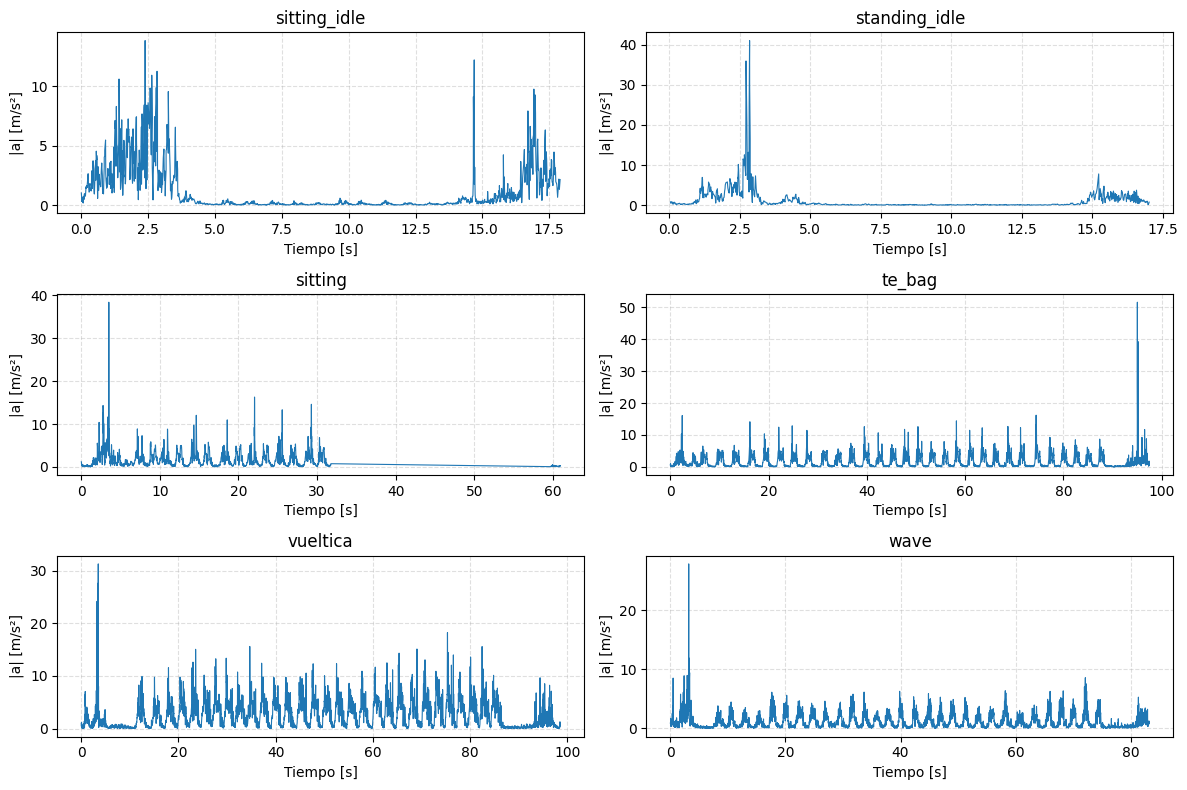

In [4]:
plt.figure(figsize=(12, 8))

for i, (name, df) in enumerate(data.items(), 1):
    plt.subplot(3, 2, i)  # 6 gráficos (3 filas, 2 columnas)
    plt.plot(df['time'], df['aT'], linewidth=0.8)
    plt.title(name)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('|a| [m/s²]')
    plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# BLOQUE 3: VISUALIZACIÓN POR EJES

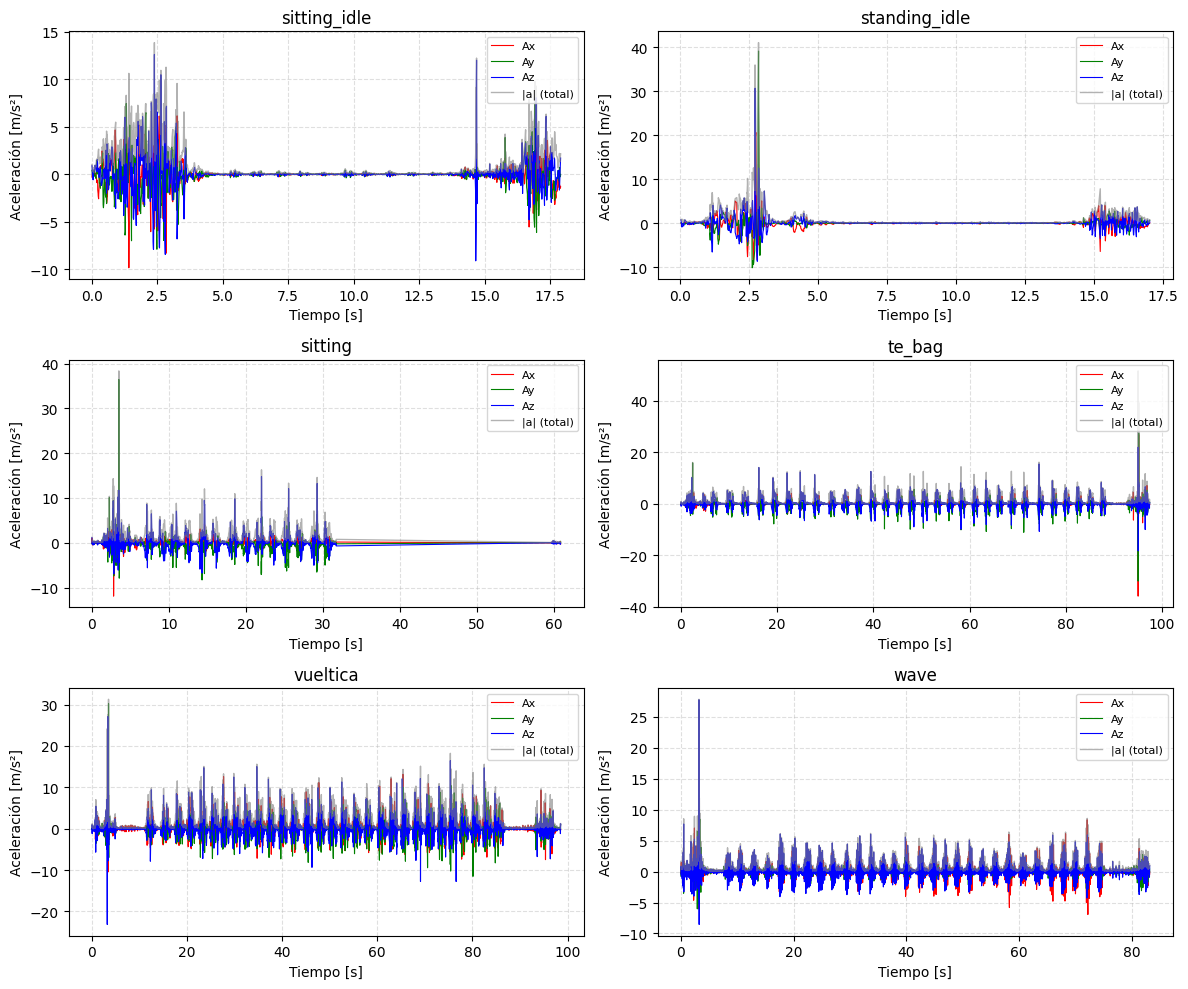

In [5]:
plt.figure(figsize=(12, 10))

for i, (name, df) in enumerate(data.items(), 1):
    plt.subplot(3, 2, i)
    
    # Graficar los ejes
    plt.plot(df['time'], df['ax'], color='r', label='Ax', linewidth=0.8)
    plt.plot(df['time'], df['ay'], color='g', label='Ay', linewidth=0.8)
    plt.plot(df['time'], df['az'], color='b', label='Az', linewidth=0.8)
    
    # Magnitud total en gris
    plt.plot(df['time'], df['aT'], color='gray', linewidth=1.0, alpha=0.6, label='|a| (total)')
    
    plt.title(name)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Aceleración [m/s²]')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# BLOQUE 4: ESTADÍSTICAS Y VISUALIZACIÓN DEL RUIDO


sitting_idle: muestras=1737, duration=17.90s, dt_med=0.0110s, fs≈91.3Hz
 Estadísticas (mean ± std):
  ax: -0.0197 ± 1.1579 (min -9.8412, max 7.0964)
  ay: -0.1014 ± 1.1724 (min -7.8838, max 7.4564)
  az: 0.0672 ± 1.4685 (min -9.1115, max 12.6237)
  aT: 1.1346 ± 1.8970 (min 0.0000, max 13.8700)


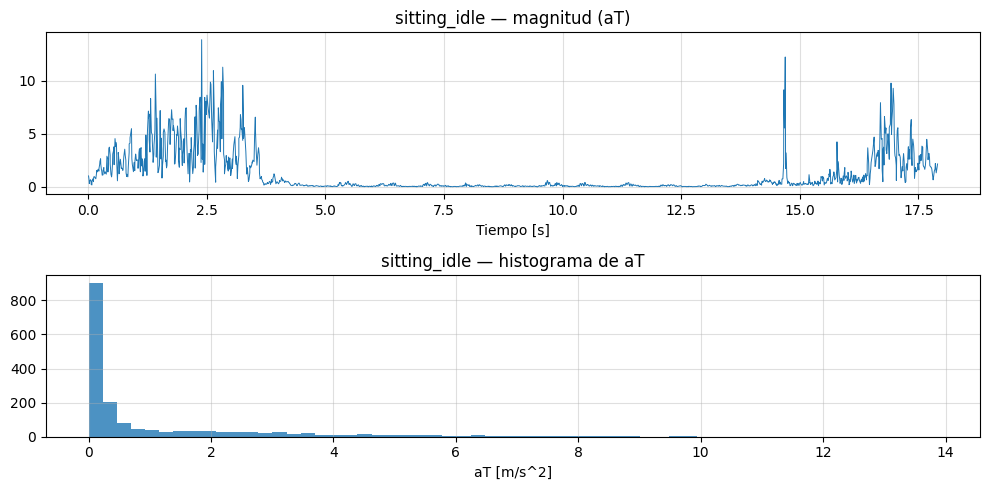


standing_idle: muestras=1434, duration=17.03s, dt_med=0.0106s, fs≈94.6Hz
 Estadísticas (mean ± std):
  ax: -0.0481 ± 1.2601 (min -8.3902, max 20.5848)
  ay: -0.0413 ± 1.7677 (min -10.1557, max 39.0852)
  az: 0.1159 ± 1.4919 (min -8.6778, max 30.6463)
  aT: 1.0173 ± 2.4331 (min 0.0100, max 41.0100)


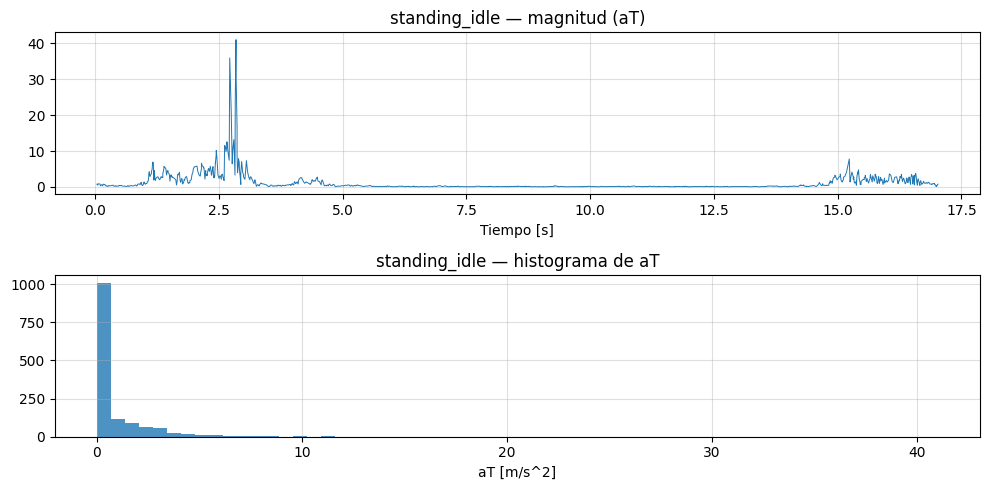

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Asumo que ya ejecutaste el BLOQUE 1 y tienes el dict `data`
idle_names = ['sitting_idle', 'standing_idle']

for name in idle_names:
    df = data[name].copy()
    # Estimación de fs a partir de time
    dt = df['time'].diff().median()
    fs = 1.0 / dt if dt>0 else None
    print(f"\n{name}: muestras={len(df)}, duration={df['time'].iloc[-1]:.2f}s, dt_med={dt:.4f}s, fs≈{fs:.1f}Hz")

    # Estadísticas por eje y magnitud
    stats = {}
    for col in ['ax','ay','az','aT']:
        stats[col] = {
            'mean': df[col].mean(),
            'std': df[col].std(),
            'min': df[col].min(),
            'max': df[col].max()
        }
    print(" Estadísticas (mean ± std):")
    for c, s in stats.items():
        print(f"  {c}: {s['mean']:.4f} ± {s['std']:.4f} (min {s['min']:.4f}, max {s['max']:.4f})")

    # Gráfica: series y histograma de aT
    fig, axes = plt.subplots(2,1, figsize=(10,5))
    axes[0].plot(df['time'], df['aT'], linewidth=0.7)
    axes[0].set_title(f"{name} — magnitud (aT)")
    axes[0].set_xlabel('Tiempo [s]')
    axes[0].grid(True, alpha=0.4)

    axes[1].hist(df['aT'], bins=60, alpha=0.8)
    axes[1].set_title(f"{name} — histograma de aT")
    axes[1].set_xlabel('aT [m/s^2]')
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()


# BLOQUE 4: FILTRADO PASA-BAJAS (BUTTERWORTH) Y COMPARACIÓN CRUDO vs FILTRADO

fs estimada = 105.0 Hz, filtro Butterworth order=4, fc=4.0 Hz


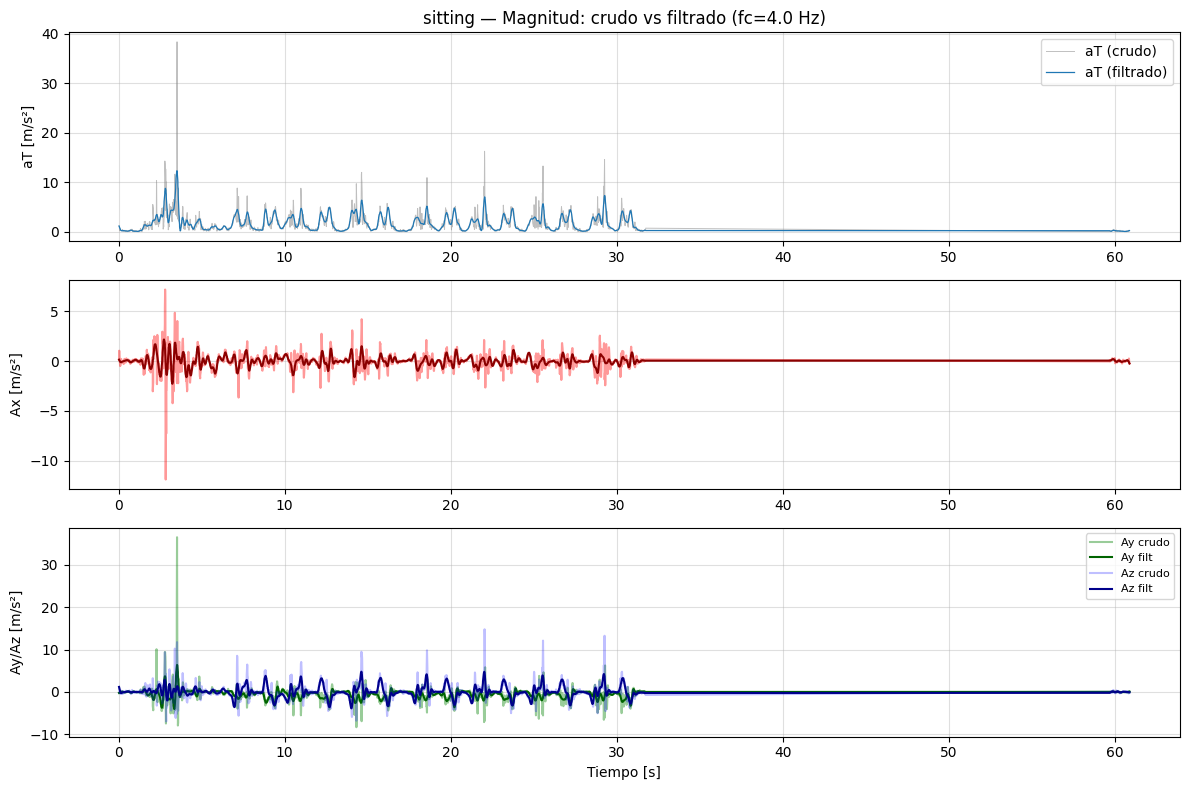

In [7]:
# BLOQUE B: 
from scipy.signal import butter, filtfilt

def design_butter_lowpass(fc, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = fc / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_filter_series(df, cols=['ax','ay','az','aT'], fc=4.0, order=4):
    # estimar fs desde time
    dt = df['time'].diff().median()
    fs = 1.0/dt
    b, a = design_butter_lowpass(fc, fs, order=order)
    df_f = df.copy()
    for c in cols:
        df_f[c + '_filt'] = filtfilt(b, a, df[c].values)
    return df_f, fs

# Parámetros del filtro
fc = 4.0   # frecuencia de corte recomendada (Hz)
order = 4

# Aplica filtro a 'sitting' (puedes cambiar a otros nombres)
name = 'sitting'
df = data[name].copy()
df_filt, fs_est = apply_filter_series(df, cols=['ax','ay','az','aT'], fc=fc, order=order)
print(f"fs estimada = {fs_est:.1f} Hz, filtro Butterworth order={order}, fc={fc} Hz")

# Gráfica: crudo vs filtrado (aT) y ejes
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(df['time'], df['aT'], alpha=0.5, linewidth=0.7, label='aT (crudo)', color='gray')
plt.plot(df_filt['time'], df_filt['aT_filt'], linewidth=0.9, label='aT (filtrado)')
plt.title(f"{name} — Magnitud: crudo vs filtrado (fc={fc} Hz)")
plt.ylabel('aT [m/s²]')
plt.legend()
plt.grid(True, alpha=0.4)

plt.subplot(3,1,2)
plt.plot(df['time'], df['ax'], alpha=0.4, label='Ax crudo', color='r')
plt.plot(df_filt['time'], df_filt['ax_filt'], label='Ax filt', color='darkred')
plt.ylabel('Ax [m/s²]')
plt.grid(True, alpha=0.4)

plt.subplot(3,1,3)
plt.plot(df['time'], df['ay'], alpha=0.4, label='Ay crudo', color='g')
plt.plot(df_filt['time'], df_filt['ay_filt'], label='Ay filt', color='darkgreen')
plt.plot(df['time'], df['az'], alpha=0.25, label='Az crudo', color='b')
plt.plot(df_filt['time'], df_filt['az_filt'], label='Az filt', color='darkblue')
plt.ylabel('Ay/Az [m/s²]')
plt.xlabel('Tiempo [s]')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# BLOQUE 5: FILTRO PASA-BAJAS BUTTERWORTH Y VISUALIZACIÓN

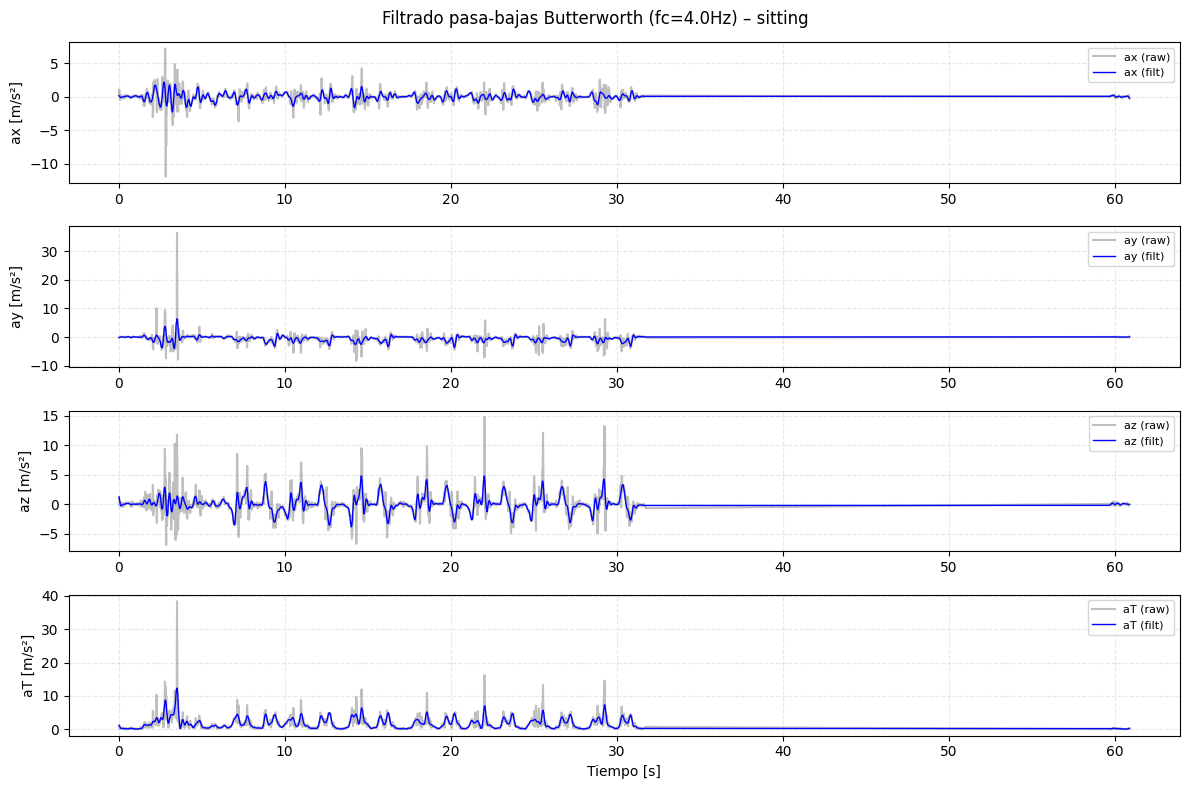

In [8]:
# --- parámetros del filtro ---
order = 4
fc = 4.0  # frecuencia de corte [Hz]
fs = 105.0  # frecuencia de muestreo estimada
w = fc / (fs / 2)  # frecuencia normalizada

b, a = butter(order, w, btype='low')

def filtrar(df):
    df_f = df.copy()
    for col in ['ax', 'ay', 'az', 'aT']:
        df_f[col] = filtfilt(b, a, df[col])
    return df_f

# archivo de ejemplo
nombre = 'sitting'
df_raw = data[nombre]
df_filt = filtrar(df_raw)

# --- GRAFICAR ---
plt.figure(figsize=(12, 8))

for i, eje in enumerate(['ax', 'ay', 'az', 'aT'], 1):
    plt.subplot(4, 1, i)
    plt.plot(df_raw['time'], df_raw[eje], label=f'{eje} (raw)', color='gray', alpha=0.5)
    plt.plot(df_filt['time'], df_filt[eje], label=f'{eje} (filt)', color='blue', linewidth=1)
    plt.ylabel(f'{eje} [m/s²]')
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.3)

plt.xlabel('Tiempo [s]')
plt.suptitle(f'Filtrado pasa-bajas Butterworth (fc={fc}Hz) – {nombre}', fontsize=12)
plt.tight_layout()
plt.show()


# BLOQUE 6: DETECCIÓN DE PICOS EN aT PARA SEGMENTACIÓN DE MOVIMIENTOS

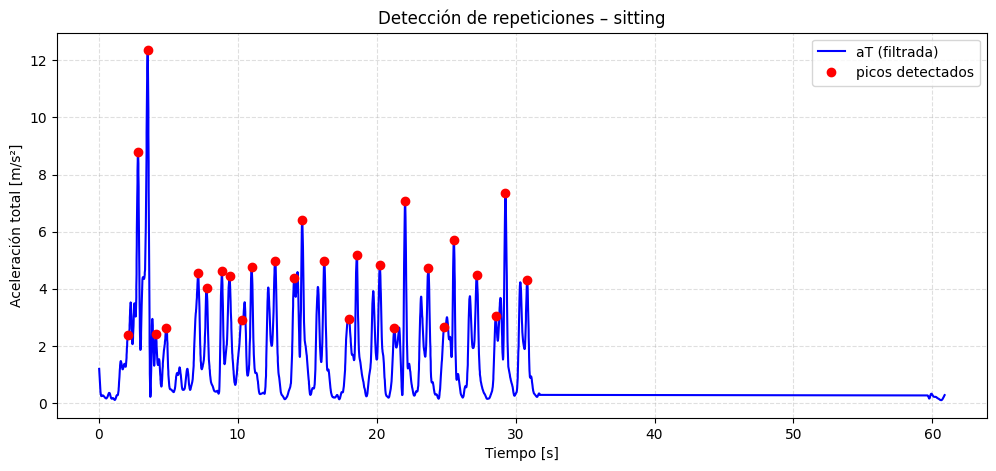

Se detectaron 27 posibles repeticiones.


In [9]:
# Elegir el dataset de ejemplo (usa el mismo que filtraste)
nombre = 'sitting'
df = filtrar(data[nombre])  # aseguramos que esté filtrado

# --- Detectar picos ---
# Ajusta 'height' y 'distance' según la frecuencia de tus repeticiones
peaks, props = find_peaks(df['aT'], height=1.5, distance=fs*0.5)  
# 'height' define el umbral mínimo de aceleración
# 'distance' evita detectar picos demasiado seguidos (~0.5 s entre ellos)

# --- Visualizar ---
plt.figure(figsize=(12, 5))
plt.plot(df['time'], df['aT'], label='aT (filtrada)', color='blue')
plt.plot(df['time'][peaks], df['aT'][peaks], 'ro', label='picos detectados')
plt.title(f'Detección de repeticiones – {nombre}')
plt.xlabel('Tiempo [s]')
plt.ylabel('Aceleración total [m/s²]')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

print(f"Se detectaron {len(peaks)} posibles repeticiones.")


# BLOQUE 7: SEGMENTACIÓN Y CREACIÓN DE DATASET (USANDO aT)


In [10]:

import numpy as np
from scipy.signal import find_peaks

# parámetros
fs = 105.0          # frecuencia de muestreo
win_t = 1.5         # ventana total [s]
half_win = int((win_t / 2) * fs)  # mitad de la ventana en muestras
height = 1.5        # umbral mínimo para detectar un movimiento
distance = fs * 0.5 # distancia mínima entre picos

# nombres de archivos de movimientos activos
movements = ['sitting', 'te_bag', 'vueltica', 'wave']

X = []
Y = []

for mov in movements:
    df = filtrar(data[mov])  # aplicar filtro pasa-bajas
    
    # detección de picos en la magnitud total
    peaks, props = find_peaks(df['aT'], height=height, distance=distance)
    
    for p in peaks:
        start = max(0, p - half_win)
        end = min(len(df), p + half_win)
        segment = df['aT'].iloc[start:end].values
        
        # asegurar longitud fija (rellenar con ceros si es necesario)
        if len(segment) < 2 * half_win:
            segment = np.pad(segment, (0, 2 * half_win - len(segment)))
        
        X.append(segment)
        Y.append(mov)

X = np.array(X)
Y = np.array(Y)

print(f"✅ Dataset construido exitosamente.")
print(f"Total de muestras: {len(Y)}")
print(f"Clases: {set(Y)}")
print(f"Shape de X: {X.shape}  (muestras, timesteps)")


✅ Dataset construido exitosamente.
Total de muestras: 201
Clases: {np.str_('te_bag'), np.str_('vueltica'), np.str_('wave'), np.str_('sitting')}
Shape de X: (201, 156)  (muestras, timesteps)


In [11]:
# Esto es para verifica rque cada clase tenga una cantidad similar de muestras
# Los datos son satisfactorios y listos para entrenar un modelo
from collections import Counter
Counter(Y)


Counter({np.str_('vueltica'): 79,
 np.str_('te_bag'): 53,
 np.str_('wave'): 42,
 np.str_('sitting'): 27})

# BLOQUE 8: ENTRENAMIENTO Y EVALUACIÓN (MLPClassifier)

=== Classification Report ===
              precision    recall  f1-score   support

     sitting       0.86      0.86      0.86         7
      te_bag       0.90      0.69      0.78        13
    vueltica       0.95      0.90      0.92        20
        wave       0.73      1.00      0.85        11

    accuracy                           0.86        51
   macro avg       0.86      0.86      0.85        51
weighted avg       0.88      0.86      0.86        51



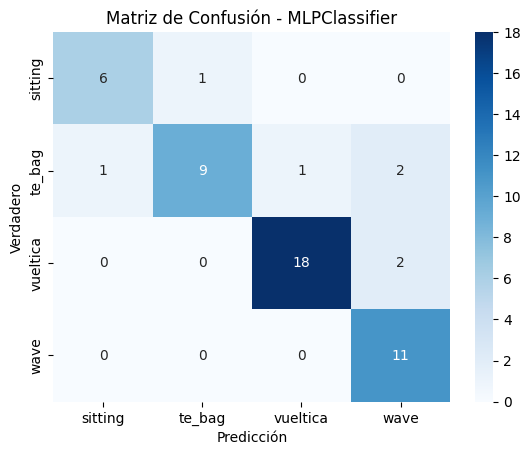

Accuracy del modelo: 86.27%


In [12]:
# Separar datos
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

# 2Normalizar (por columna temporal)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo base
clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                    solver='adam', max_iter=300, random_state=42)
clf.fit(X_train_scaled, y_train)

# Evaluar
y_pred = clf.predict(X_test_scaled)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Matriz de Confusión - MLPClassifier")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

print(f"Accuracy del modelo: {clf.score(X_test_scaled, y_test)*100:.2f}%")


# BLOQUE 9: Visualización de las separaciones de clase


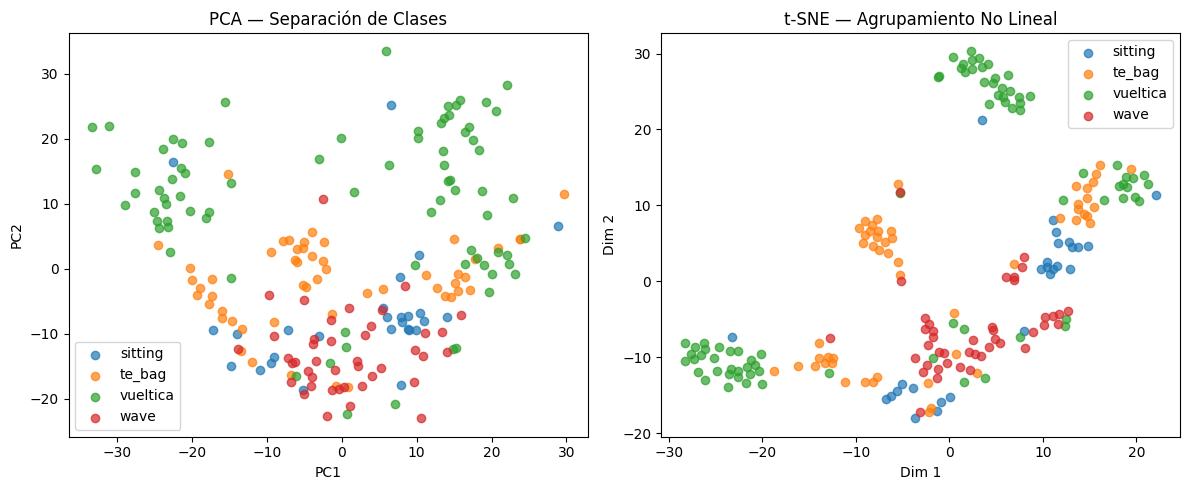

In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reducir dimensionalidad con PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Reducir dimensionalidad con t-SNE (2D)
X_tsne = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(X)

# --- GRAFICAR ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# PCA
for lbl in np.unique(Y):
    idx = Y == lbl
    axs[0].scatter(X_pca[idx, 0], X_pca[idx, 1], label=lbl, alpha=0.7)
axs[0].set_title("PCA — Separación de Clases")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")
axs[0].legend()

# t-SNE
for lbl in np.unique(Y):
    idx = Y == lbl
    axs[1].scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=lbl, alpha=0.7)
axs[1].set_title("t-SNE — Agrupamiento No Lineal")
axs[1].set_xlabel("Dim 1")
axs[1].set_ylabel("Dim 2")
axs[1].legend()

plt.tight_layout()
plt.show()


# Bloque 10: Métricas

In [14]:
# Reentrenar para medir tiempo
t0 = time.time()
clf.fit(X_train_scaled, y_train)
train_time = time.time() - t0

# Tiempo promedio de inferencia por muestra
t1 = time.time()
_ = clf.predict(X_test_scaled)
infer_time = (time.time() - t1) / len(X_test_scaled)

# Métricas
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"=== RESUMEN DE MÉTRICAS ===")
print(f"Accuracy        : {acc:.3f}")
print(f"Precision (macro): {prec:.3f}")
print(f"Recall (macro)   : {rec:.3f}")
print(f"F1-macro         : {f1:.3f}")
print(f"Tiempo entrenamiento: {train_time:.3f} s")
print(f"Tiempo inferencia  : {infer_time*1000:.3f} ms/serie")


=== RESUMEN DE MÉTRICAS ===
Accuracy        : 0.863
Precision (macro): 0.859
Recall (macro)   : 0.862
F1-macro         : 0.852
Tiempo entrenamiento: 0.698 s
Tiempo inferencia  : 0.000 ms/serie


# Ahora pasamos a modelo B

# BLOQUE 7B — Segmentación SIN filtrado (Método B)

In [ ]:
# --- BLOQUE 7B: SEGMENTACIÓN PARA MÉTODO B (SIN FILTRADO) ---

import numpy as np
from scipy.signal import find_peaks

fs = 105.0
win_t = 1.5
half_win = int((win_t / 2) * fs)
height = 1.5
distance = fs * 0.5

movements = ['sitting', 'te_bag', 'vueltica', 'wave']

X_B = []
Y_B = []

for mov in movements:
    df = data[mov]        # <-- SIN FILTRADO
    
    peaks, props = find_peaks(df['aT'], height=height, distance=distance)
    
    for p in peaks:
        start = max(0, p - half_win)
        end = min(len(df), p + half_win)
        segment = df['aT'].iloc[start:end].values
        
        if len(segment) < 2 * half_win:
            segment = np.pad(segment, (0, 2 * half_win - len(segment)))
            
        X_B.append(segment)
        Y_B.append(mov)

X_B = np.array(X_B)
Y_B = np.array(Y_B)

print("Dataset B (sin filtrado) construido")
print("Shape:", X_B.shape, "Clases:", set(Y_B))


✅ Dataset B (sin filtrado) construido
Shape: (277, 156) Clases: {np.str_('te_bag'), np.str_('vueltica'), np.str_('wave'), np.str_('sitting')}


In [18]:
# Esto es para verifica rque cada clase tenga una cantidad similar de muestras
# Los datos son satisfactorios y listos para entrenar un modelo
from collections import Counter
Counter(Y_B)


Counter({np.str_('vueltica'): 102,
 np.str_('te_bag'): 73,
 np.str_('wave'): 67,
 np.str_('sitting'): 35})

# BLOQUE 8B: ENTRENAMIENTO Y EVALUACIÓN

=== MÉTODO B: Classification Report ===
              precision    recall  f1-score   support

     sitting       0.64      0.78      0.70         9
      te_bag       0.77      0.56      0.65        18
    vueltica       0.83      0.77      0.80        26
        wave       0.50      0.65      0.56        17

    accuracy                           0.69        70
   macro avg       0.68      0.69      0.68        70
weighted avg       0.71      0.69      0.69        70



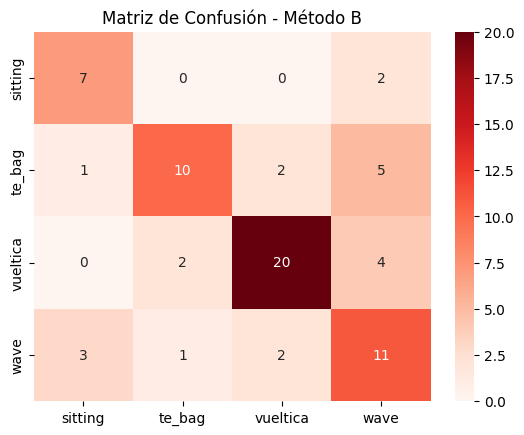

Accuracy Método B: 0.6857142857142857


In [19]:
# Separar datos
X_train, X_test, y_train, y_test = train_test_split(X_B, Y_B, test_size=0.25, random_state=42, stratify=Y_B)

scaler_B = StandardScaler()
X_train_scaled_B = scaler_B.fit_transform(X_train)
X_test_scaled_B = scaler_B.transform(X_test)

clf_B = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                      solver='adam', max_iter=300, random_state=42)
clf_B.fit(X_train_scaled_B, y_train)

y_pred_B = clf_B.predict(X_test_scaled_B)

print("=== MÉTODO B: Classification Report ===")
print(classification_report(y_test, y_pred_B))

cm = confusion_matrix(y_test, y_pred_B, labels=clf_B.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=clf_B.classes_, yticklabels=clf_B.classes_)
plt.title("Matriz de Confusión - Método B")
plt.show()

print("Accuracy Método B:", clf_B.score(X_test_scaled_B, y_test))



# BLOQUE 9B: Visualización de las separaciones de clase para B

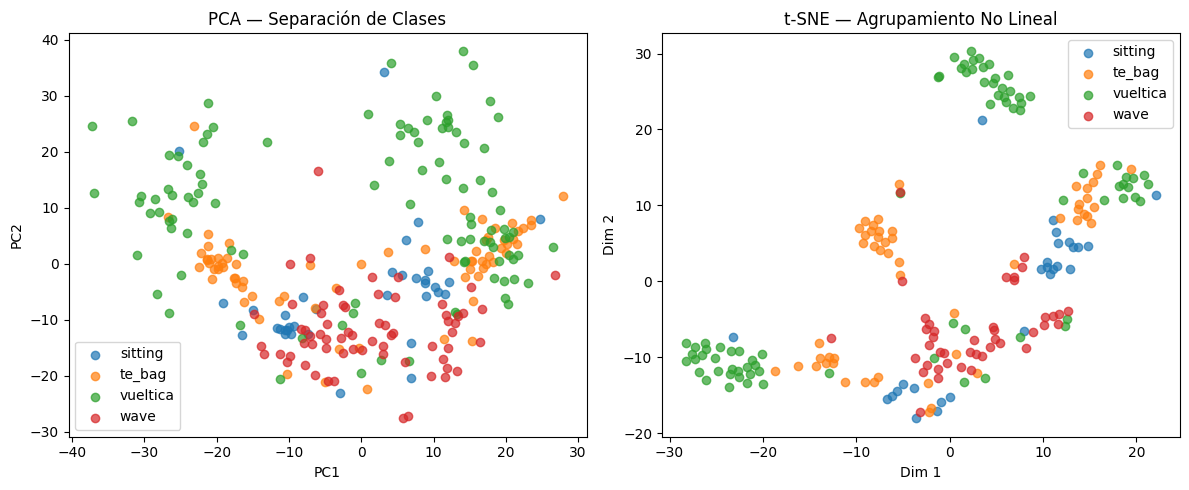

In [21]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reducir dimensionalidad con PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_B)

# Reducir dimensionalidad con t-SNE (2D)
X_tsne = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(X)

# --- GRAFICAR ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# PCA
for lbl in np.unique(Y_B):
    idx = Y_B == lbl
    axs[0].scatter(X_pca[idx, 0], X_pca[idx, 1], label=lbl, alpha=0.7)
axs[0].set_title("PCA — Separación de Clases")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")
axs[0].legend()

# t-SNE
for lbl in np.unique(Y):
    idx = Y == lbl
    axs[1].scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=lbl, alpha=0.7)
axs[1].set_title("t-SNE — Agrupamiento No Lineal")
axs[1].set_xlabel("Dim 1")
axs[1].set_ylabel("Dim 2")
axs[1].legend()

plt.tight_layout()
plt.show()


# Bloque 10: Métricas

In [22]:
t0 = time.time()
clf_B.fit(X_train_scaled_B, y_train)
train_time_B = time.time() - t0

t1 = time.time()
_ = clf_B.predict(X_test_scaled_B)
infer_time_B = (time.time() - t1) / len(X_test_scaled_B)

acc_B = accuracy_score(y_test, y_pred_B)
prec_B, rec_B, f1_B, _ = precision_recall_fscore_support(y_test, y_pred_B, average='macro')

print("=== RESUMEN MÉTODO B ===")
print("Accuracy:", acc_B)
print("Precision:", prec_B)
print("Recall:", rec_B)
print("F1:", f1_B)
print("Tiempo entrenamiento:", train_time_B)
print("Tiempo inferencia:", infer_time_B * 1000, "ms")


=== RESUMEN MÉTODO B ===
Accuracy: 0.6857142857142857
Precision: 0.6847319347319347
Recall: 0.6874057315233786
F1: 0.6773159636062862
Tiempo entrenamiento: 1.26485013961792
Tiempo inferencia: 0.0 ms


# BLOQUE DE COMPARACIÓN (MÉTODO A vs MÉTODO B)


=== TABLA COMPARATIVA A vs B ===
                        Métrica  Método A  Método B
0                      Accuracy  0.862745  0.685714
1                      F1-macro  0.852246  0.677316
2             Precision (macro)  0.859461  0.684732
3                Recall (macro)  0.862363  0.687406
4      Tiempo entrenamiento [s]  0.702835  0.984167
5  Tiempo inferencia [ms/serie]  0.000000  0.000000


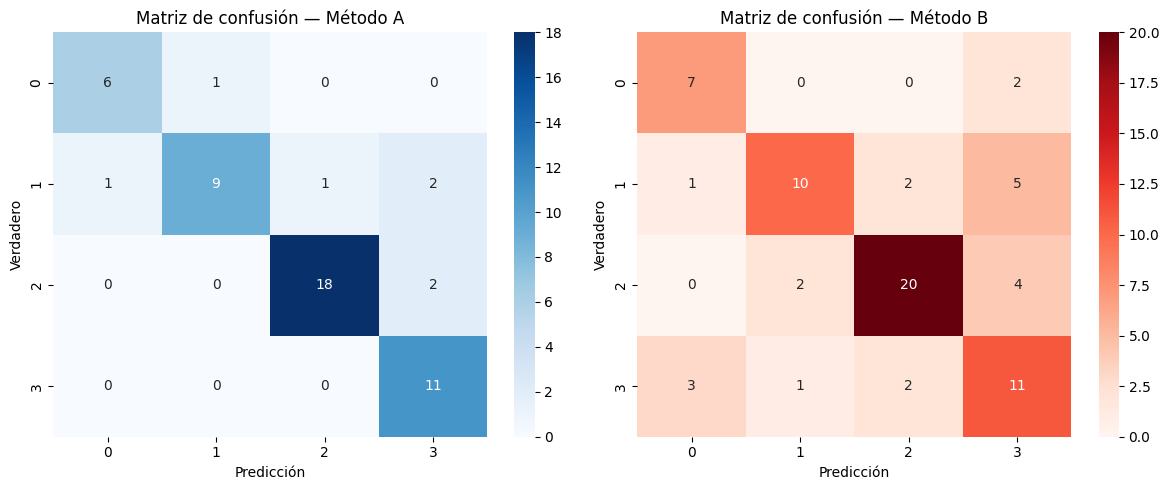

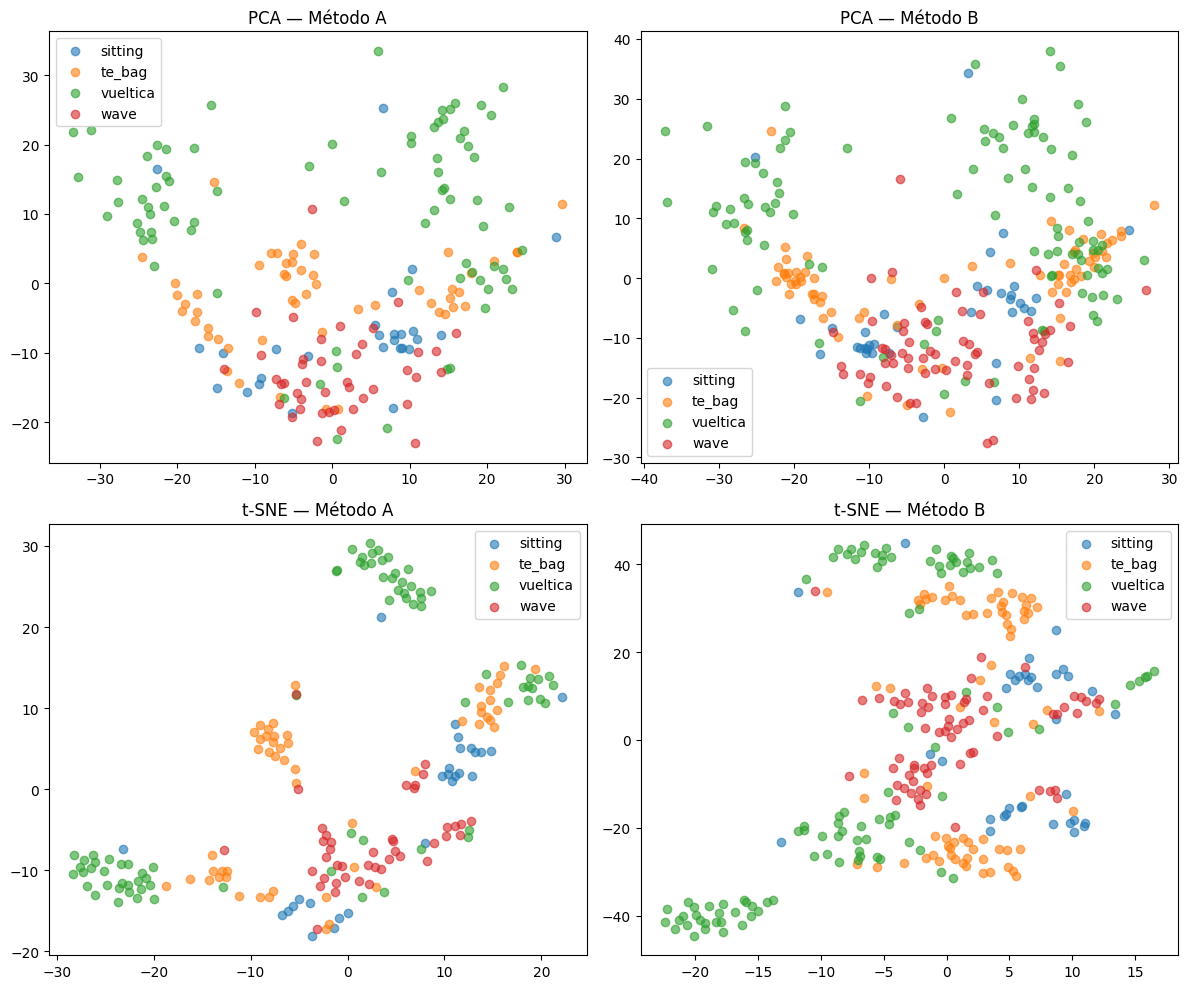

In [24]:
# Método A

X_A = X     # dataset filtrado
Y_A = Y

# Train/test split
XA_train, XA_test, yA_train, yA_test = train_test_split(
    X_A, Y_A, test_size=0.25, random_state=42, stratify=Y_A
)

# Normalización
scaler_A = StandardScaler()
XA_train_s = scaler_A.fit_transform(XA_train)
XA_test_s  = scaler_A.transform(XA_test)

# Entrenamiento + tiempo
t0 = time.time()
clf_A = MLPClassifier(hidden_layer_sizes=(100,50), activation="relu",
                      solver="adam", max_iter=300, random_state=42)
clf_A.fit(XA_train_s, yA_train)
t_train_A = time.time() - t0

# Inferencia + tiempo
t1 = time.time()
yA_pred = clf_A.predict(XA_test_s)
t_inf_A = (time.time() - t1) / len(XA_test_s)

# Métricas
acc_A  = accuracy_score(yA_test, yA_pred)
prec_A, rec_A, f1_A, _ = precision_recall_fscore_support(yA_test, yA_pred, average="macro")


# Método B

# Ya tienes X_B, Y_B del bloque 7B

# Train/test split
XB_train, XB_test, yB_train, yB_test = train_test_split(
    X_B, Y_B, test_size=0.25, random_state=42, stratify=Y_B
)

# Normalización
scaler_B = StandardScaler()
XB_train_s = scaler_B.fit_transform(XB_train)
XB_test_s  = scaler_B.transform(XB_test)

# Entrenamiento + tiempo
t0 = time.time()
clf_B = MLPClassifier(hidden_layer_sizes=(100,50), activation="relu",
                      solver="adam", max_iter=300, random_state=42)
clf_B.fit(XB_train_s, yB_train)
t_train_B = time.time() - t0

# Inferencia + tiempo
t1 = time.time()
yB_pred = clf_B.predict(XB_test_s)
t_inf_B = (time.time() - t1) / len(XB_test_s)

# Métricas
acc_B  = accuracy_score(yB_test, yB_pred)
prec_B, rec_B, f1_B, _ = precision_recall_fscore_support(yB_test, yB_pred, average="macro")


# Gráficas (Esto si es 100% ChatGPT porque es repetir lo anterior pero comparando)

tabla = pd.DataFrame({
    "Métrica": ["Accuracy", "F1-macro", "Precision (macro)", "Recall (macro)",
                "Tiempo entrenamiento [s]", "Tiempo inferencia [ms/serie]"],
    "Método A": [acc_A, f1_A, prec_A, rec_A, t_train_A, t_inf_A*1000],
    "Método B": [acc_B, f1_B, prec_B, rec_B, t_train_B, t_inf_B*1000]
})

print("\n=== TABLA COMPARATIVA A vs B ===")
print(tabla)

# ============================
# 4. Matrices de confusión
# ============================

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(yA_test, yA_pred), annot=True, fmt='d',
            cmap='Blues', ax=axs[0])
axs[0].set_title("Matriz de confusión — Método A")
axs[0].set_xlabel("Predicción"); axs[0].set_ylabel("Verdadero")

sns.heatmap(confusion_matrix(yB_test, yB_pred), annot=True, fmt='d',
            cmap='Reds', ax=axs[1])
axs[1].set_title("Matriz de confusión — Método B")
axs[1].set_xlabel("Predicción"); axs[1].set_ylabel("Verdadero")

plt.tight_layout()
plt.show()

# Gráficas PCA y t-SNE

pcaA = PCA(n_components=2).fit_transform(X_A)
pcaB = PCA(n_components=2).fit_transform(X_B)

tsneA = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(X_A)
tsneB = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(X_B)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for lbl in np.unique(Y_A):
    idx = Y_A == lbl
    axs[0,0].scatter(pcaA[idx,0], pcaA[idx,1], label=lbl, alpha=0.6)
axs[0,0].set_title("PCA — Método A")

for lbl in np.unique(Y_B):
    idx = Y_B == lbl
    axs[0,1].scatter(pcaB[idx,0], pcaB[idx,1], label=lbl, alpha=0.6)
axs[0,1].set_title("PCA — Método B")

for lbl in np.unique(Y_A):
    idx = Y_A == lbl
    axs[1,0].scatter(tsneA[idx,0], tsneA[idx,1], label=lbl, alpha=0.6)
axs[1,0].set_title("t-SNE — Método A")

for lbl in np.unique(Y_B):
    idx = Y_B == lbl
    axs[1,1].scatter(tsneB[idx,0], tsneB[idx,1], label=lbl, alpha=0.6)
axs[1,1].set_title("t-SNE — Método B")

for ax in axs.flatten():
    ax.legend()

plt.tight_layout()
plt.show()
